In [361]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [362]:
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint as print
from xsynth.signal import ADAPTSignalGenerator

from xsynth.device import (ADAPTX)

In [365]:
AX = ADAPTX(beam_region = "SA3")

In [366]:
XSynth = ADAPTSignalGenerator(AX, oscillator='sin')
XSynth.update_variable(V0 = 2000, V1 = 2350, V2 = 5)
XSynth.write()

Failed to write to Adaptation Server: {'code': 102, 'message': 'RPC: Authentication error'}


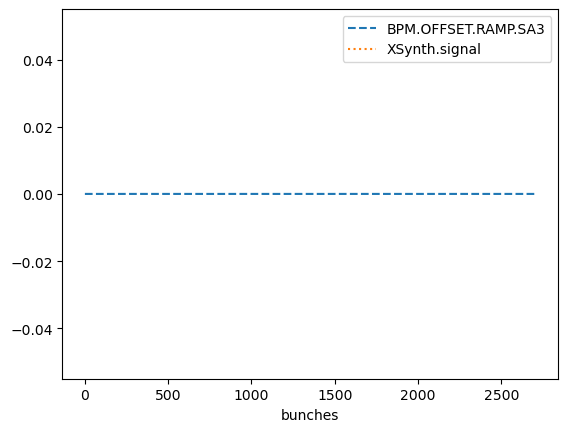

In [367]:
plt.plot(np.arange(2708), XSynth.server.read(), label = XSynth.server.ramp_location.split("/")[-1], linestyle = 'dashed')
plt.plot(XSynth.t, XSynth.signal, label = "XSynth.signal", linestyle = 'dotted')
plt.xlabel(XSynth.unit)
#plt.xlim(XSynth.t.min(), XSynth.t.max())
plt.legend()


In [368]:
from xsynth.main import Scan
from functools import partial

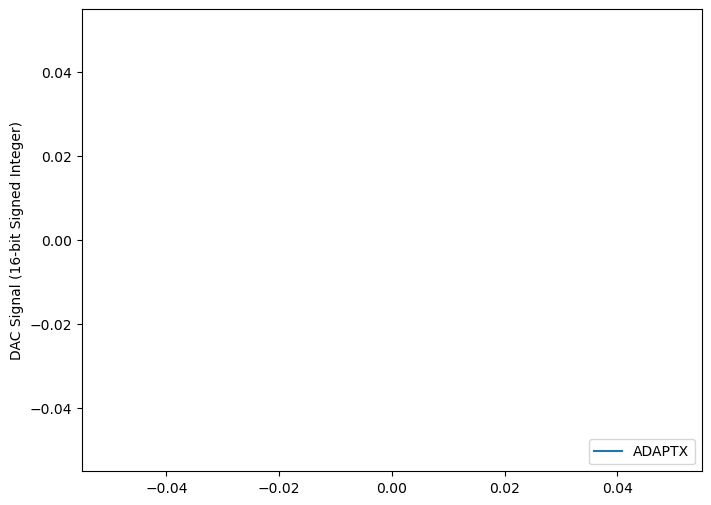

In [369]:
scan_output = Scan([partial(ADAPTX, beam_region='SA3')],
            scan_vectors = [np.arange(10)],
            all_messages=False,
            display = True,
            beam_region = 'SA3',
			wait_time=1,
			write = False,
			relative_scan = False,
			oscillator_variables=[{"V0":0,"V1":2708}],
			oscillators=['sin'],
		scan_variables=['V2'],
			
            )

##### NEXT STEP IS TO GET PLOTTING WORKING

In [370]:
#print(scan_output.__dict__)
print(scan_output.generators[0].server.pulseId)

array([682], dtype=uint32)


In [371]:
import pydoocs
pydoocs.read(f"XFEL.FEEDBACK/KICKERDC_BETA/CONTROL/BPM.PULSES.SA2.INDX")['data']

array([160], dtype=uint32)